In [60]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [61]:
import kagglehub
path = kagglehub.dataset_download("dongeorge/seed-from-uci")

Using Colab cache for faster access to the 'seed-from-uci' dataset.


In [62]:
# Download and Load Dataset
df = pd.read_csv("/kaggle/input/seed-from-uci/Seed_Data.csv")

In [63]:
# Basic Dataset Exploration
print(df.head())

       A      P       C     LK     WK  A_Coef    LKG  target
0  15.26  14.84  0.8710  5.763  3.312   2.221  5.220       0
1  14.88  14.57  0.8811  5.554  3.333   1.018  4.956       0
2  14.29  14.09  0.9050  5.291  3.337   2.699  4.825       0
3  13.84  13.94  0.8955  5.324  3.379   2.259  4.805       0
4  16.14  14.99  0.9034  5.658  3.562   1.355  5.175       0


In [64]:
print(df.columns)

Index(['A', 'P', 'C', 'LK', 'WK', 'A_Coef', 'LKG', 'target'], dtype='object')


In [65]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       210 non-null    float64
 1   P       210 non-null    float64
 2   C       210 non-null    float64
 3   LK      210 non-null    float64
 4   WK      210 non-null    float64
 5   A_Coef  210 non-null    float64
 6   LKG     210 non-null    float64
 7   target  210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.3 KB
None


In [66]:
print(df.isnull().sum())

A         0
P         0
C         0
LK        0
WK        0
A_Coef    0
LKG       0
target    0
dtype: int64


In [67]:
print(df.duplicated().sum())

0


In [68]:
print(df.nunique())

A         193
P         170
C         186
LK        188
WK        184
A_Coef    207
LKG       148
target      3
dtype: int64


In [69]:
print(df.describe())

                A           P           C          LK          WK      A_Coef  \
count  210.000000  210.000000  210.000000  210.000000  210.000000  210.000000   
mean    14.847524   14.559286    0.870999    5.628533    3.258605    3.700201   
std      2.909699    1.305959    0.023629    0.443063    0.377714    1.503557   
min     10.590000   12.410000    0.808100    4.899000    2.630000    0.765100   
25%     12.270000   13.450000    0.856900    5.262250    2.944000    2.561500   
50%     14.355000   14.320000    0.873450    5.523500    3.237000    3.599000   
75%     17.305000   15.715000    0.887775    5.979750    3.561750    4.768750   
max     21.180000   17.250000    0.918300    6.675000    4.033000    8.456000   

              LKG      target  
count  210.000000  210.000000  
mean     5.408071    1.000000  
std      0.491480    0.818448  
min      4.519000    0.000000  
25%      5.045000    0.000000  
50%      5.223000    1.000000  
75%      5.877000    2.000000  
max      6.550

In [70]:
# Exploratory Data Analysis (EDA)
# Check Target Class Distribution
print(df["target"].value_counts())
print(df["target"].value_counts(normalize=True) * 100)

target
0    70
1    70
2    70
Name: count, dtype: int64
target
0    33.333333
1    33.333333
2    33.333333
Name: proportion, dtype: float64


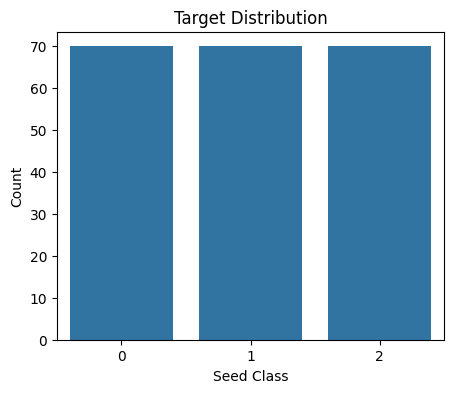

In [71]:
# Visualize Target Class Distribution
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="target")
plt.xlabel("Seed Class")
plt.ylabel("Count")
plt.title("Target Distribution")
plt.show()

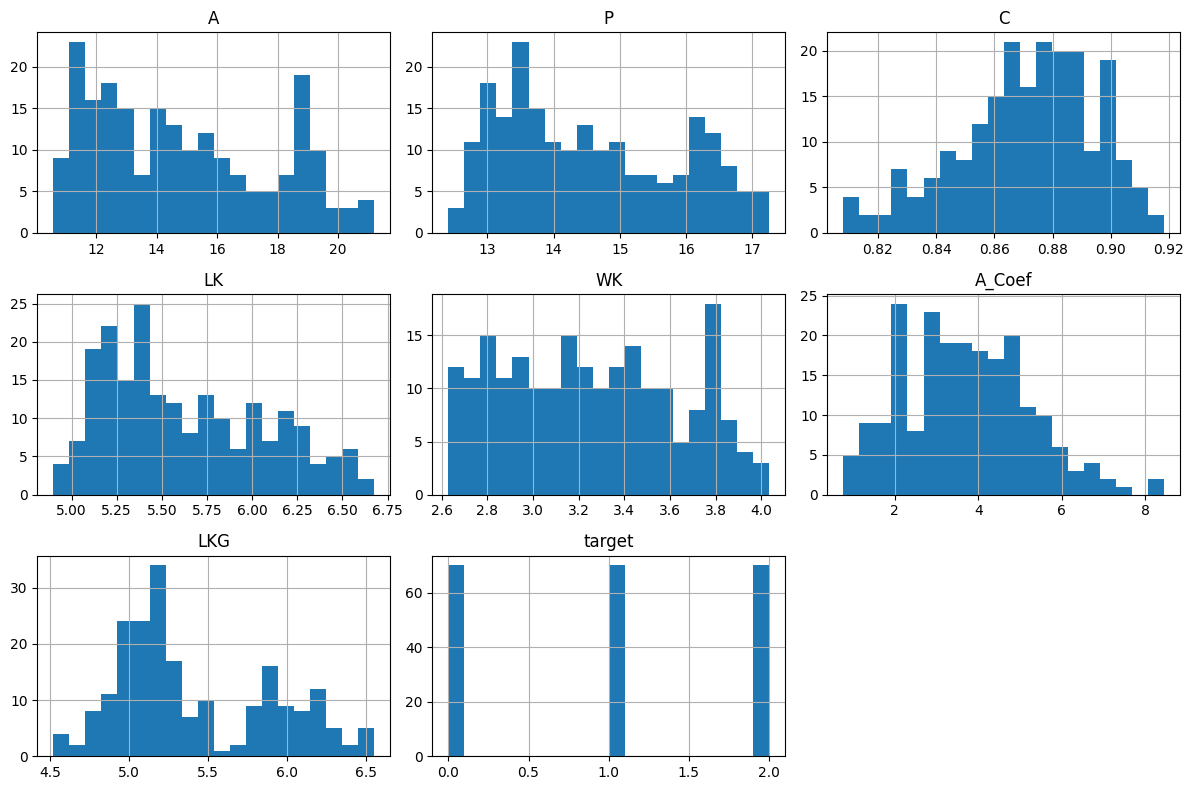

In [72]:
# Visualize Feature Distributions
df.hist(figsize=(12,8),bins=20)
plt.tight_layout()
plt.show()

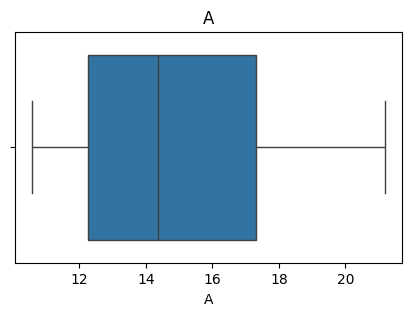

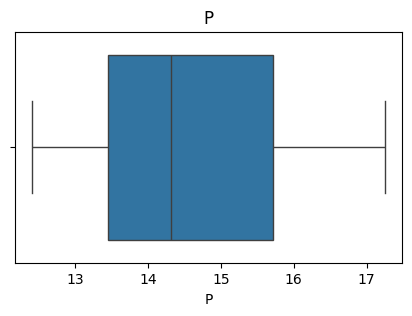

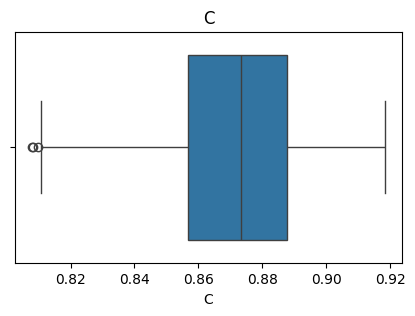

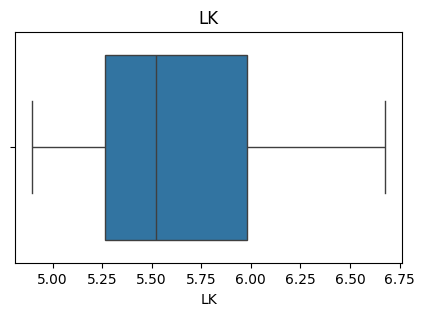

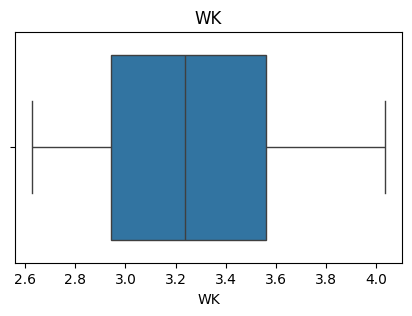

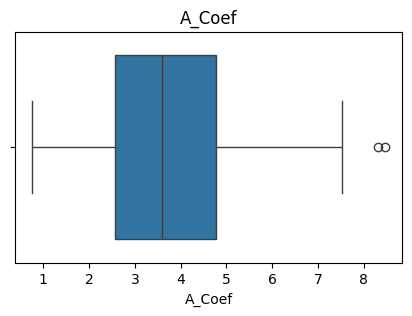

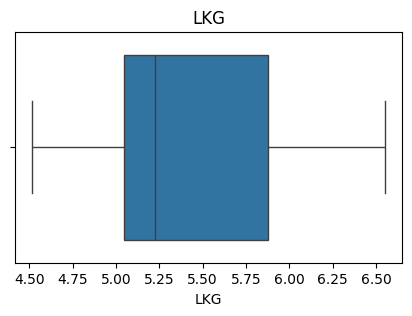

In [73]:
# Detect Potential Outliers
for col in df.columns[:-1]:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

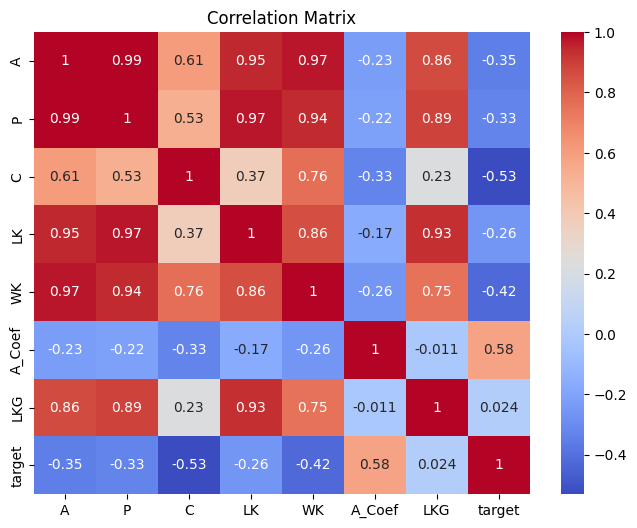

In [74]:
# Correlation Analysis
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [75]:
# Feature Selection

X = df.drop("target", axis=1)
y = df["target"]

In [76]:
# Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [77]:
import kagglehub
path = kagglehub.dataset_download("dongeorge/seed-from-uci")

Using Colab cache for faster access to the 'seed-from-uci' dataset.


In [78]:
# Download and Load Dataset
df = pd.read_csv("/kaggle/input/seed-from-uci/Seed_Data.csv")

In [79]:
# Basic Dataset Exploration
print(df.head())

       A      P       C     LK     WK  A_Coef    LKG  target
0  15.26  14.84  0.8710  5.763  3.312   2.221  5.220       0
1  14.88  14.57  0.8811  5.554  3.333   1.018  4.956       0
2  14.29  14.09  0.9050  5.291  3.337   2.699  4.825       0
3  13.84  13.94  0.8955  5.324  3.379   2.259  4.805       0
4  16.14  14.99  0.9034  5.658  3.562   1.355  5.175       0


In [80]:
print(df.columns)

Index(['A', 'P', 'C', 'LK', 'WK', 'A_Coef', 'LKG', 'target'], dtype='object')


In [81]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A       210 non-null    float64
 1   P       210 non-null    float64
 2   C       210 non-null    float64
 3   LK      210 non-null    float64
 4   WK      210 non-null    float64
 5   A_Coef  210 non-null    float64
 6   LKG     210 non-null    float64
 7   target  210 non-null    int64  
dtypes: float64(7), int64(1)
memory usage: 13.3 KB
None


In [82]:
print(df.isnull().sum())

A         0
P         0
C         0
LK        0
WK        0
A_Coef    0
LKG       0
target    0
dtype: int64


In [83]:
print(df.duplicated().sum())

0


In [84]:
print(df.nunique())

A         193
P         170
C         186
LK        188
WK        184
A_Coef    207
LKG       148
target      3
dtype: int64


In [85]:
print(df.describe())

                A           P           C          LK          WK      A_Coef  \
count  210.000000  210.000000  210.000000  210.000000  210.000000  210.000000   
mean    14.847524   14.559286    0.870999    5.628533    3.258605    3.700201   
std      2.909699    1.305959    0.023629    0.443063    0.377714    1.503557   
min     10.590000   12.410000    0.808100    4.899000    2.630000    0.765100   
25%     12.270000   13.450000    0.856900    5.262250    2.944000    2.561500   
50%     14.355000   14.320000    0.873450    5.523500    3.237000    3.599000   
75%     17.305000   15.715000    0.887775    5.979750    3.561750    4.768750   
max     21.180000   17.250000    0.918300    6.675000    4.033000    8.456000   

              LKG      target  
count  210.000000  210.000000  
mean     5.408071    1.000000  
std      0.491480    0.818448  
min      4.519000    0.000000  
25%      5.045000    0.000000  
50%      5.223000    1.000000  
75%      5.877000    2.000000  
max      6.550

In [86]:
# Exploratory Data Analysis (EDA)
# Check Target Class Distribution
print(df["target"].value_counts())
print(df["target"].value_counts(normalize=True) * 100)

target
0    70
1    70
2    70
Name: count, dtype: int64
target
0    33.333333
1    33.333333
2    33.333333
Name: proportion, dtype: float64


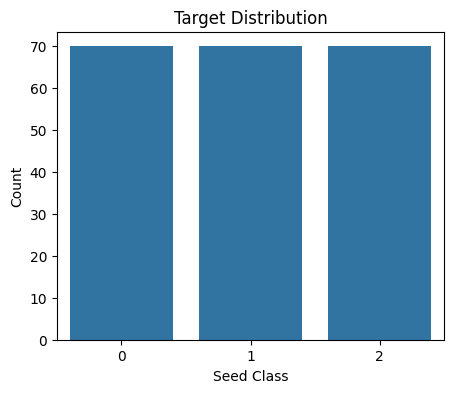

In [87]:
# Visualize Target Class Distribution
plt.figure(figsize=(5,4))
sns.countplot(data=df, x="target")
plt.xlabel("Seed Class")
plt.ylabel("Count")
plt.title("Target Distribution")
plt.show()

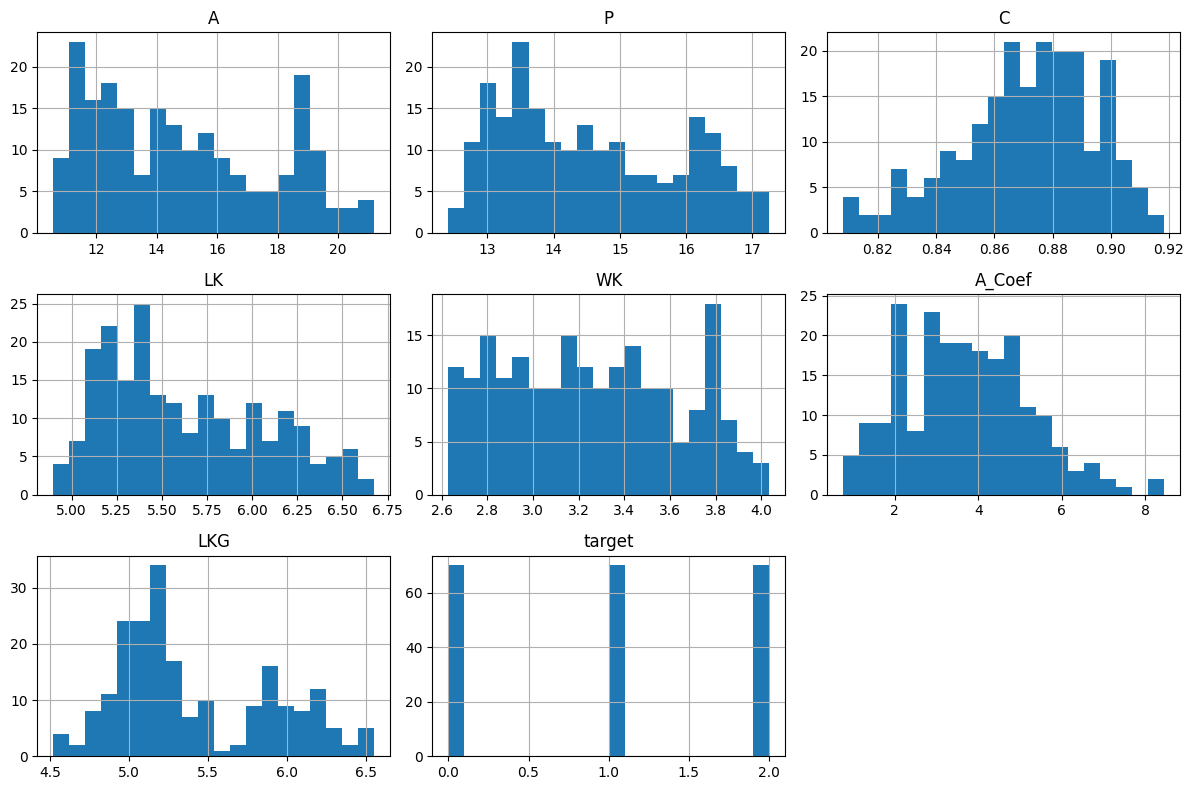

In [88]:
# Visualize Feature Distributions
df.hist(figsize=(12,8),bins=20)
plt.tight_layout()
plt.show()

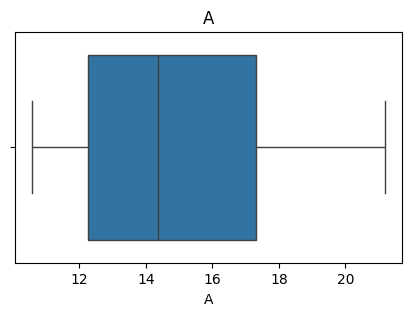

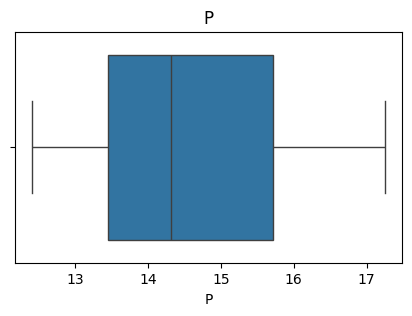

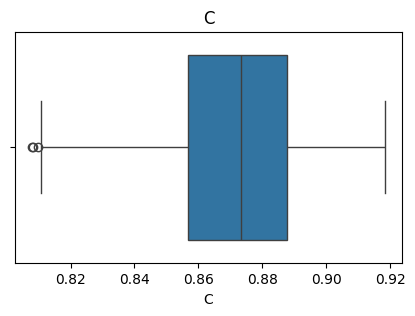

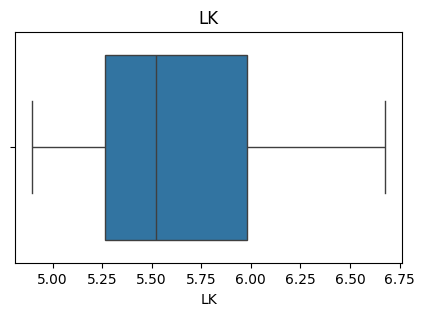

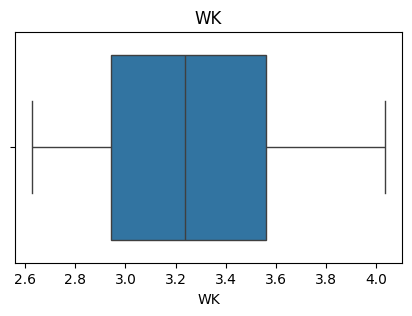

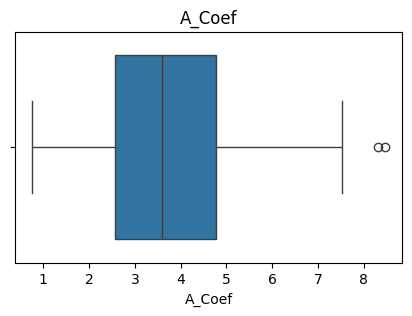

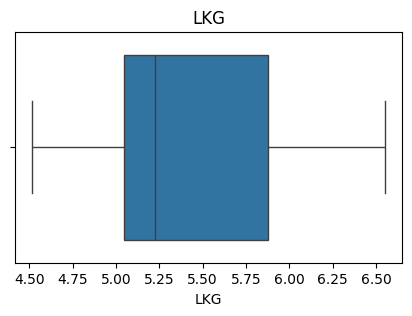

In [89]:
# Detect Potential Outliers
for col in df.columns[:-1]:
    plt.figure(figsize=(5,3))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()

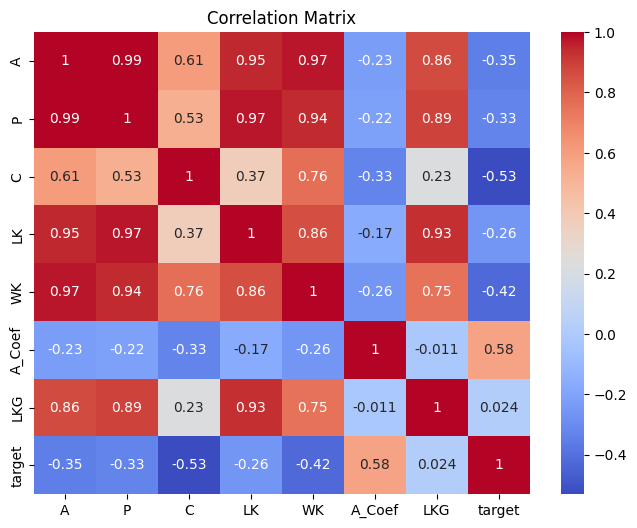

In [90]:
# Correlation Analysis
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [91]:
# Feature Selection
# Separate Features and Target Variable
X = df.drop("target", axis=1)
y = df["target"]

In [92]:
# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(168, 7)
(42, 7)


In [93]:
# Feature Scaling
# Standardize Features for Distance-Based Models
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [94]:
# Model Training
# K-Nearest Neighbors (KNN)
knn = KNeighborsClassifier()
knn.fit(X_train_scaled,y_train)
knn_pred = knn.predict(X_test_scaled)

In [95]:
# Support Vector Machine (SVM)
svm = SVC(random_state=42)
svm.fit(X_train_scaled,y_train)
svm_pred = svm.predict(X_test_scaled)

In [96]:
# Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)
dt_pred = dt.predict(X_test)

In [97]:
# Model Evaluation
results = {
    "Model":[],
    "Accuracy":[],
    "Precision":[],
    "Recall":[],
    "F1 Score":[]
}

models = {
    "KNN":knn_pred,
    "SVM":svm_pred,
    "Decision Tree":dt_pred
}

for name,pred in models.items():

    results["Model"].append(name)

    results["Accuracy"].append(
        accuracy_score(y_test,pred)
    )

    results["Precision"].append(
        precision_score(y_test,pred,average="weighted")
    )

    results["Recall"].append(
        recall_score(y_test,pred,average="weighted")
    )

    results["F1 Score"].append(
        f1_score(y_test,pred,average="weighted")
    )

comparison = pd.DataFrame(results)

print(comparison)

           Model  Accuracy  Precision    Recall  F1 Score
0            KNN  0.904762   0.916667  0.904762  0.900000
1            SVM  0.904762   0.916667  0.904762  0.900000
2  Decision Tree  0.880952   0.883586  0.880952  0.876628


In [98]:
# Save Final Model
joblib.dump(knn,"seeds_classifier.pkl")
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [99]:
# Split Dataset
# Separate Features and Target Variable
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(168, 7)
(42, 7)


In [100]:
# Feature Scaling
# Standardize Features for Distance-Based Models
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [101]:
# Model Training
# K-Nearest Neighbors (KNN)
knn = KNeighborsClassifier()
knn.fit(X_train_scaled,y_train)
knn_pred = knn.predict(X_test_scaled)

In [102]:
# Support Vector Machine (SVM)
svm = SVC(random_state=42)
svm.fit(X_train_scaled,y_train)
svm_pred = svm.predict(X_test_scaled)

In [103]:
# Decision Tree Classifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train,y_train)
dt_pred = dt.predict(X_test)

In [104]:
# Model Evaluation
results = {
    "Model":[],
    "Accuracy":[],
    "Precision":[],
    "Recall":[],
    "F1 Score":[]
}

models = {
    "KNN":knn_pred,
    "SVM":svm_pred,
    "Decision Tree":dt_pred
}

for name,pred in models.items():

    results["Model"].append(name)

    results["Accuracy"].append(
        accuracy_score(y_test,pred)
    )

    results["Precision"].append(
        precision_score(y_test,pred,average="weighted")
    )

    results["Recall"].append(
        recall_score(y_test,pred,average="weighted")
    )

    results["F1 Score"].append(
        f1_score(y_test,pred,average="weighted")
    )

comparison = pd.DataFrame(results)

print(comparison)

           Model  Accuracy  Precision    Recall  F1 Score
0            KNN  0.904762   0.916667  0.904762  0.900000
1            SVM  0.904762   0.916667  0.904762  0.900000
2  Decision Tree  0.880952   0.883586  0.880952  0.876628


In [105]:
# Save Final Model
joblib.dump(knn, "seeds_classification_model.pkl")
joblib.dump(scaler, "standard_scaler.pkl")

['standard_scaler.pkl']